<a href="https://www.kaggle.com/code/sonawanelalitsunil/top-100-trending-hits-2025-eda-ml-100?scriptVersionId=265008696" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-100-trending-music-on-youtube/youtube-top-100-songs-2025.csv


## 🎵 Top 100 Trending Hits 2025 | YouTube’s Biggest Music Chart

## Detailed Description:
Discover the hottest 100 trending songs on YouTube in 2025! From chart-topping pop anthems to viral hits across genres, this playlist brings you the latest tracks that everyone is listening to. Perfect for music lovers, parties, workouts, or just vibing to the newest sounds.

Stay updated with YouTube’s most popular music, enjoy the hottest artists, and never miss a viral track again.

## Import dataset

In [2]:
df  = pd.read_csv("/kaggle/input/top-100-trending-music-on-youtube/youtube-top-100-songs-2025.csv")

In [3]:
df.head()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxres...,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...","Lady Gaga, Bruno Mars - Die With A Smile (Offi...",MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...,1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefau...,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,Reneé Rapp - Leave Me Alone (Official Music Vi...,"Listen to “BITE ME”, the new album from Reneé ...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,Billie Eilish - BIRDS OF A FEATHER (Official M...,Listen to HIT ME HARD AND SOFT: https://billie...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alte...,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefau...,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé ...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000


In [4]:
df.tail()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
95,Ariana Grande - twilight zone (Official Lyric ...,Ariana Grande - twilight zone (Official Lyric ...,The official “twilight zone” official lyric vi...,18245315,Music,Ariana Grande;Republic Records;Pop,202,3:22,False,https://i.ytimg.com/vi/x1XIJM6spaE/maxresdefau...,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...","Gracie Abrams - I Love You, I’m Sorry (Officia...","Listen to the new album, The Secret of Us, out...",31456772,Music,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,3:54,False,https://i.ytimg.com/vi/uxjhN_Donfw/maxresdefau...,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000
97,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino and FCG Heem drop Miami. From...,66051,Music,NaN,197,3:17,False,https://i.ytimg.com/vi_webp/I-gmbHgeN1I/maxres...,HoodTrophy Bino,https://www.youtube.com/channel/UCsaZi3QZrZ5-s...,20300
98,Sean Paul x INNA - Let It Talk To Me,Sean Paul x INNA - Let It Talk To Me,Song Title: Sean Paul x INNA - Let It Talk To ...,16952860,Music,Sean Paul,155,2:35,False,https://i.ytimg.com/vi_webp/nkRyAVQdqAA/maxres...,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000
99,"Selena Gomez, benny blanco - How Does It Feel ...","Selena Gomez, benny blanco - How Does It Feel ...",Listen to the new album 'I Said I Love You Fir...,16971256,Music,Selena Gomez;benny blanco;SMG Music LLC Friend...,161,2:41,False,https://i.ytimg.com/vi/4LcNr0T2yAA/maxresdefau...,Selena Gomez,https://www.youtube.com/channel/UCjK8ORC71kwyj...,35500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   title                   100 non-null    object
 1   fulltitle               100 non-null    object
 2   description             100 non-null    object
 3   view_count              100 non-null    int64 
 4   categories              100 non-null    object
 5   tags                    85 non-null     object
 6   duration                100 non-null    int64 
 7   duration_string         100 non-null    object
 8   live_status             100 non-null    bool  
 9   thumbnail               100 non-null    object
 10  channel                 100 non-null    object
 11  channel_url             100 non-null    object
 12  channel_follower_count  100 non-null    int64 
dtypes: bool(1), int64(3), object(9)
memory usage: 9.6+ KB


In [6]:
df.isnull().sum()

title                      0
fulltitle                  0
description                0
view_count                 0
categories                 0
tags                      15
duration                   0
duration_string            0
live_status                0
thumbnail                  0
channel                    0
channel_url                0
channel_follower_count     0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.nunique()

title                     100
fulltitle                 100
description               100
view_count                100
categories                  2
tags                       76
duration                   69
duration_string            69
live_status                 1
thumbnail                 100
channel                    65
channel_url                69
channel_follower_count     65
dtype: int64

In [9]:
df.describe().loc[['mean','min','max']].T

,mean,min,max
view_count,1.059103e+08,1161.0,2.009015e+09
duration,2.039000e+02,120.0,3.540000e+02
channel_follower_count,1.612067e+07,1.0,7.620000e+07


In [10]:
df.dtypes

title                     object
fulltitle                 object
description               object
view_count                 int64
categories                object
tags                      object
duration                   int64
duration_string           object
live_status                 bool
thumbnail                 object
channel                   object
channel_url               object
channel_follower_count     int64
dtype: object

In [11]:
df.columns

Index(['title', 'fulltitle', 'description', 'view_count', 'categories', 'tags',
       'duration', 'duration_string', 'live_status', 'thumbnail', 'channel',
       'channel_url', 'channel_follower_count'],
      dtype='object')

## Data visualizations

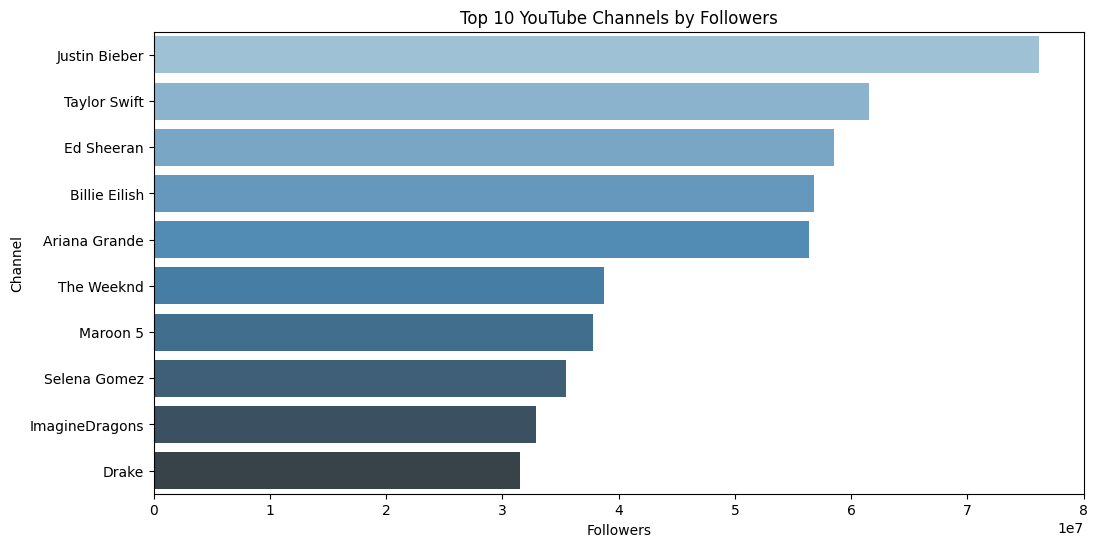

In [12]:
top_channels = df.groupby('channel')['channel_follower_count'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_channels.values, y=top_channels.index, palette='Blues_d')
plt.title('Top 10 YouTube Channels by Followers')
plt.xlabel('Followers')
plt.ylabel('Channel')
plt.show()


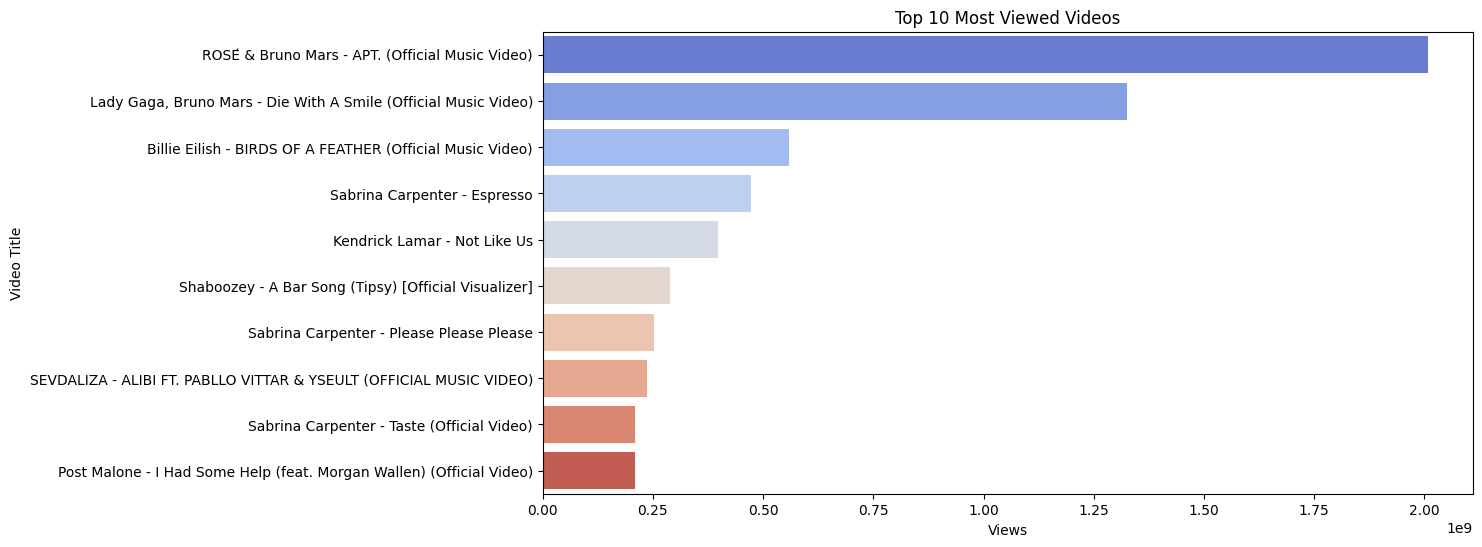

In [13]:
top_videos = df.sort_values('view_count', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_videos['view_count'], y=top_videos['title'], palette='coolwarm')
plt.title('Top 10 Most Viewed Videos')
plt.xlabel('Views')
plt.ylabel('Video Title')
plt.show()

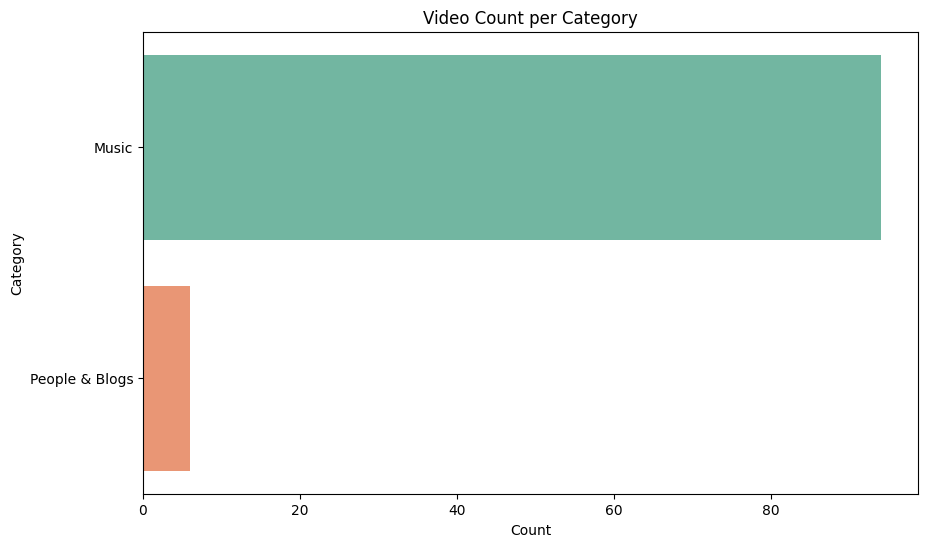

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(y='categories', data=df, order=df['categories'].value_counts().index, palette='Set2')
plt.title('Video Count per Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

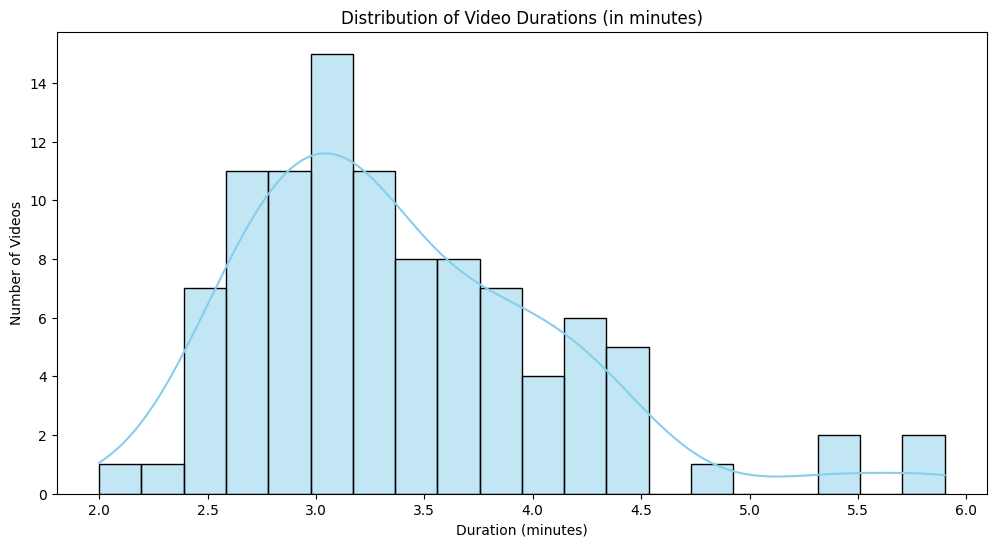

In [15]:
def duration_to_minutes(dur):
    parts = dur.split(':')
    if len(parts) == 3:  # HH:MM:SS
        return int(parts[0])*60 + int(parts[1]) + int(parts[2])/60
    elif len(parts) == 2:  # MM:SS
        return int(parts[0]) + int(parts[1])/60
    return 0

df['duration_min'] = df['duration_string'].apply(duration_to_minutes)

plt.figure(figsize=(12,6))
sns.histplot(df['duration_min'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Video Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Videos')
plt.show()

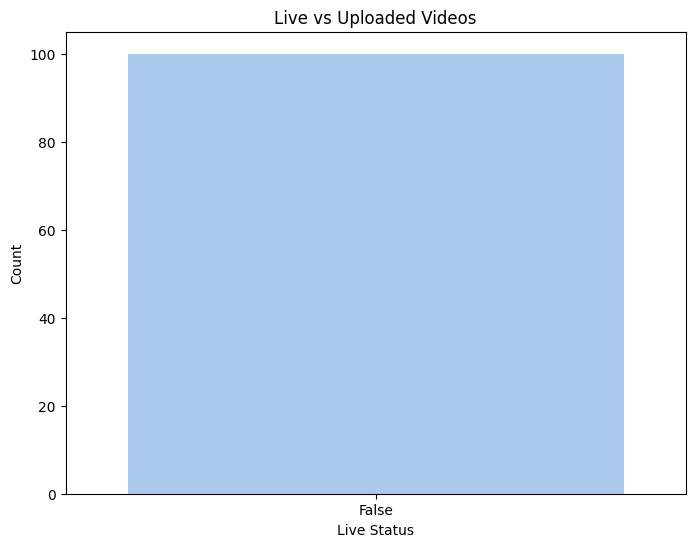

In [16]:
plt.figure(figsize=(8,6))
sns.countplot(x='live_status', data=df, palette='pastel')
plt.title('Live vs Uploaded Videos')
plt.xlabel('Live Status')
plt.ylabel('Count')
plt.show()

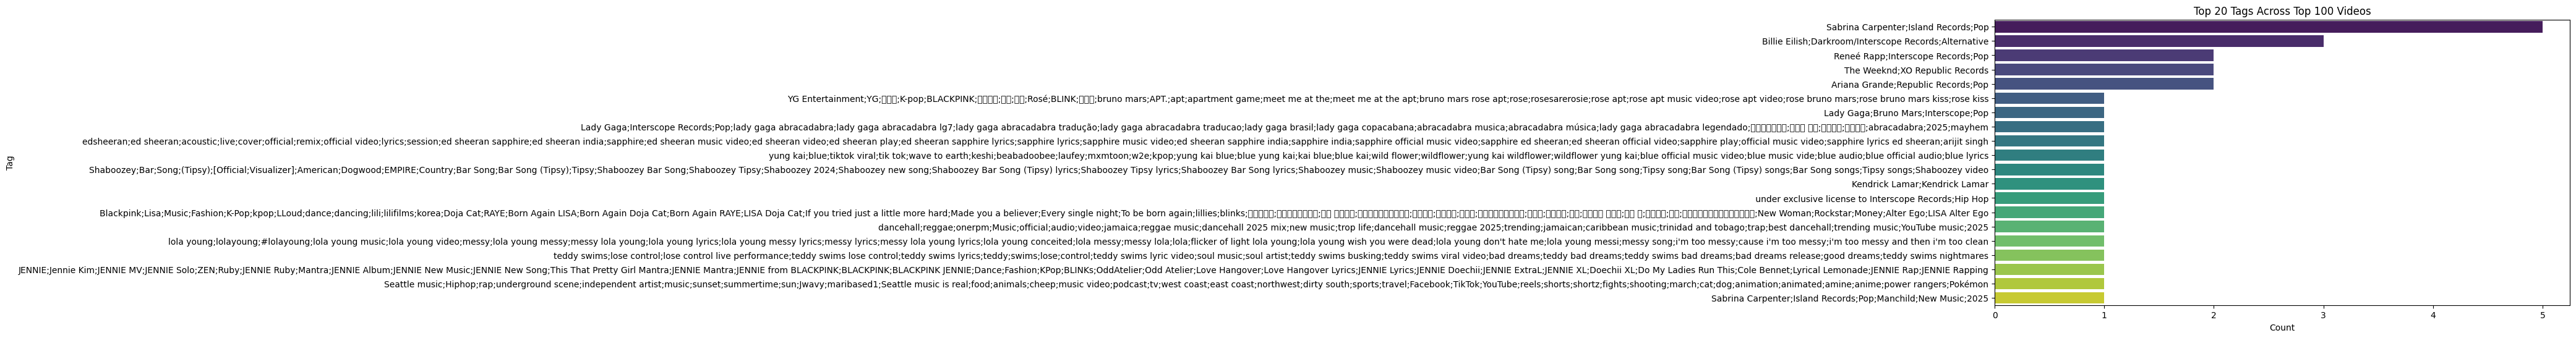

In [17]:
from collections import Counter

# Flatten all tags (assuming they are comma-separated)
all_tags = df['tags'].dropna().str.split(',').sum()
top_tags = Counter(all_tags).most_common(20)

tags_df = pd.DataFrame(top_tags, columns=['tag','count'])
plt.figure(figsize=(12,6))
sns.barplot(x='count', y='tag', data=tags_df, palette='viridis')
plt.title('Top 20 Tags Across Top 100 Videos')
plt.xlabel('Count')
plt.ylabel('Tag')
plt.show()

## ML Algorithms

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [19]:
features = ['view_count', 'duration']  # numeric features
categorical = ['live_status', 'channel', 'categories']  # categorical features

# Fill missing values
df['duration'].fillna(df['duration'].mean(), inplace=True)
df['view_count'].fillna(df['view_count'].mean(), inplace=True)


In [20]:
le_dict = {}
for col in categorical:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [21]:
X = df[features + categorical]
y = df['categories']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC()
}

accuracy_dict = {}

In [24]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_dict[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 90.00%
Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%
Gradient Boosting Accuracy: 100.00%
SVM Accuracy: 90.00%


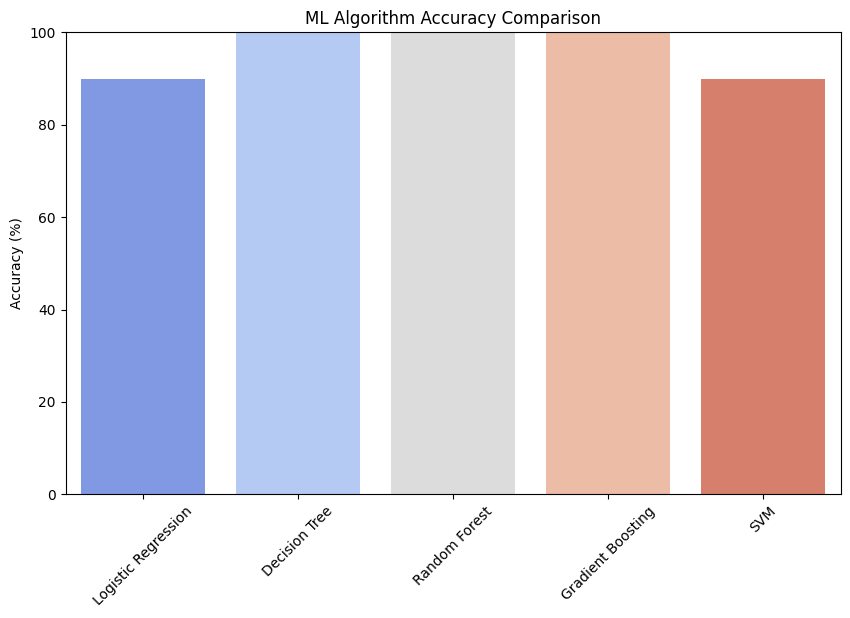

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='coolwarm')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.title('ML Algorithm Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()

## Thank you..pls upvote!!!